In [1]:
import os
import random
import time
import h5py
import numpy as np
import pandas as pd
import scipy.io
import librosa
import kagglehub
import h5py
import shutil
import IPython.display as ipd
import matplotlib.pyplot as plt

from IPython.display import display, Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score 
#from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import Rocket
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report
from detach_rocket.detach_classes import DetachRocket
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sktime.classification.kernel_based import RocketClassifier


In [2]:
# ==================================================
# 2. CARGA Y CONCATENACIÓN DE BABBLE NOISE (LOCAL)
# ==================================================
babble_exact_path = "datasets/noise/0dB/valid/real" 

audio_buffers_list = []
max_archivos_a_combinar = 40 
sr_original = 16000
sr_objetivo = 22050

archivos_mat = 0

for f in os.listdir(babble_exact_path):
    if len(audio_buffers_list) >= max_archivos_a_combinar:
        break

    file_path = os.path.join(babble_exact_path, f)
    
    if file_path.endswith('.mat'):
            mat_contents = scipy.io.loadmat(file_path) #esta funcion convierte el .mat en un diccionario 
            keys = [k for k in mat_contents.keys() if not k.startswith('__')] # cuando SciPy lee un .mat, automáticamente le inyecta variables internas de configuración que siempre empiezan con doble guion bajo (ej: __header. 
            #armo una lista solo con los nombres de las variables "reales" que contienen el audio
            if keys:
                audio_raw = mat_contents[keys[0]].flatten().astype(np.float32) 
                #mat_contents[keys[0]] extrae los datos almacenados en la primera clave válida
                # .flatten(): "aplasta" esa matriz para convertirla en un vector 1D
                # .astype(np.float32): conversión a formato decimal de 32 bits (float32).
                if audio_raw.size > 0:
                    audio_buffers_list.append(audio_raw)
                    archivos_mat += 1

# Procesamiento final
print("-" * 50)
print(f" - Archivos .mat procesados: {archivos_mat}")



--------------------------------------------------
 - Archivos .mat procesados: 40


In [3]:
babble_completo_16k = np.concatenate(audio_buffers_list)
babble_audio_full = librosa.resample(babble_completo_16k, orig_sr=sr_original, target_sr=sr_objetivo) #la paso a la sample rate que necesito

In [4]:
# ==================================================
# 3. FUNCIONES DE DATA AUGMENTATION
# ==================================================

#RUIDO BLANCO
def add_white_noise(audio, noise_level=0.005):
    noise = np.random.randn(len(audio)) #vector de numeros aleatorios con la misma longitud que mi vector original
    return audio + noise_level * noise

In [5]:
#RUIDO ROSA
def add_pink_noise(audio, noise_level=0.01):
    #el ruido rosa se caracteriza por tener una densidad espectral inversa a la frecuencia (es decir, 1/f)
    white = np.random.randn(len(audio)) #genero ruido blanco
    fft_white = np.fft.rfft(white) #transformada de fourier - paso el ruido blanco a dominio de la frecuencia. Ya no es la potencia, es la amplitud la que veo representada
    frequencies = np.maximum(np.fft.rfftfreq(len(audio)), 1e-10) #crea un vector de frecuencias. SI hay un valor menor a 1e-10, lo reemplaza por este número.
    #Elijo 1e-10 porque es un numero cercano a cero, sin ser cero.
    f_filter = 1.0 / np.sqrt(frequencies) #En la línea anterior, me aseguré de que no queden divisiones por cero. V^2 = P -> 1/sqrt(f) = P (ver notas)
    f_filter /= np.max(f_filter) #Busca el numero mas grande que haya quedado dentro del array y divide a todos los valores por este numero
    fft_pink = fft_white * f_filter #Aplica el filtro al ruido blanco en el dominio de la frecuencia.
    pink = np.fft.irfft(fft_pink, n=len(audio)) #Conversion al dominio del tiempo
    pink = pink / np.max(np.abs(pink)) #normalizacion
    return audio + noise_level * pink

In [7]:

#MULTITALKER BABBLE NOISE 
def add_babble_noise(audio, babble_audio, noise_level=0.03):
    # np.tile -> construye un nuevo array repitiendo el primer argumento (en este caso, babble_audio) la cantidad de veces que se pida. 
    # Esto se aplica solo si el audio es menor al audio original  
    #np.ceil -> devuelve el menor escalar i tal que i>=x
    if len(babble_audio) < len(audio):
        babble_audio = np.tile(babble_audio, int(np.ceil(len(audio) / len(babble_audio))))

    # toma un punto de inicio random
    start_idx = random.randint(0, len(babble_audio) - len(audio))
    babble_chunk = babble_audio[start_idx : start_idx + len(audio)] #aplico babble noise desde mi punto random hasta el final del audio
    babble_chunk = babble_chunk / (np.max(np.abs(babble_chunk)) + 1e-10) #normalizo el murmullo para que no haya picos de volumen descontrolados

    return audio + noise_level * babble_chunk 


In [8]:
# ==========================================
# 4. DESCARGA Y CURACIÓN DEL DATASET LOCAL
# ==========================================
dataset_root_path = kagglehub.dataset_download("mmoreaux/environmental-sound-classification-50")

metadata_path = None
for root, dirs, files in os.walk(dataset_root_path):
    if 'esc50.csv' in files:
        metadata_path = os.path.join(root, 'esc50.csv')
        break

if metadata_path:
    df = pd.read_csv(metadata_path)
    print("Archivo de metadatos cargado correctamente.")

mis_clases = ['clock_alarm', 'door_wood_knock', 'cat', 'crying_baby', 'dog', 'glass_breaking']
df_filtrado = df[df['category'].isin(mis_clases)].copy()

kaggle_audio_dir = None
for root, dirs, files in os.walk(dataset_root_path): #Busca donde estan los archivos
    if any(f.endswith('.wav') for f in files):
        kaggle_audio_dir = root
        break

target_dir = "datasets/audios_originales"
archivos_copiados = 0

for index, row in df_filtrado.iterrows():
    src_path = os.path.join(kaggle_audio_dir, row['filename'])
    dst_path = os.path.join(target_dir, row['filename'])
    
    # Solo lo copio si el archivo original existe y no esta en el directorio audios_originales
    if os.path.exists(src_path) and not os.path.exists(dst_path):
        shutil.copy2(src_path, dst_path)
        archivos_copiados += 1

print(f"Se copiaron {archivos_copiados} archivos nuevos.")


Archivo de metadatos cargado correctamente.
Se copiaron 0 archivos nuevos.


In [9]:
# ==========================================
# 5. TRANSFORMACIÓN A MFCC Y DATA AUGMENTATION
# ==========================================
correct_audio_dir = target_dir 

X_list = []
y_list = []
groups = []

# Parámetros para MFCC
n_mfcc = 40
hop_length = 512

for index, row in df_filtrado.iterrows(): 
    file_path = os.path.join(correct_audio_dir, row['filename']) 
    categoria = row['category'] 
    
    # Cargar audio original
    y_audio, sr = librosa.load(file_path, sr=22050) 

    # Generar versiones aumentadas
    audios_a_procesar = [
            y_audio,                                     
            add_white_noise(y_audio),                    
            add_pink_noise(y_audio),                     
            add_babble_noise(y_audio, babble_audio_full) 
        ]

    # Convertir cada versión a MFCC
    for audio_version in audios_a_procesar:
        # Extraer MFCCs: el resultado es (40, 216)
        mfccs = librosa.feature.mfcc(y=audio_version, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
        
        X_list.append(mfccs)
        y_list.append(categoria)
        groups.append(row['filename'])

# Convertir a arreglos de NumPy
X = np.array(X_list)
y = np.array(y_list)
groups = np.array(groups)

print("-" * 50)
print(f"Forma final de la matriz X: {X.shape}") # Debería imprimir (960, 40, 216)
print(f"Cantidad de etiquetas y: {y.shape}")

--------------------------------------------------
Forma final de la matriz X: (960, 40, 216)
Cantidad de etiquetas y: (960,)


In [12]:
groups
y

array(['dog', 'dog', 'dog', 'dog', 'door_wood_knock', 'door_wood_knock',
       'door_wood_knock', 'door_wood_knock', 'door_wood_knock',
       'door_wood_knock', 'door_wood_knock', 'door_wood_knock',
       'door_wood_knock', 'door_wood_knock', 'door_wood_knock',
       'door_wood_knock', 'dog', 'dog', 'dog', 'dog', 'clock_alarm',
       'clock_alarm', 'clock_alarm', 'clock_alarm', 'clock_alarm',
       'clock_alarm', 'clock_alarm', 'clock_alarm', 'crying_baby',
       'crying_baby', 'crying_baby', 'crying_baby', 'glass_breaking',
       'glass_breaking', 'glass_breaking', 'glass_breaking',
       'crying_baby', 'crying_baby', 'crying_baby', 'crying_baby',
       'crying_baby', 'crying_baby', 'crying_baby', 'crying_baby',
       'crying_baby', 'crying_baby', 'crying_baby', 'crying_baby',
       'crying_baby', 'crying_baby', 'crying_baby', 'crying_baby',
       'crying_baby', 'crying_baby', 'crying_baby', 'crying_baby',
       'door_wood_knock', 'door_wood_knock', 'door_wood_knock',
  

In [ ]:


from sktime.datasets import load_unit_test
X_train, y_train = load_unit_test(split="train")
X_test, y_test = load_unit_test(split="test")
print(X_train.shape)
trf = Rocket(num_kernels=512)
trf.fit(X_train)
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)
print(X_train.shape)

(20, 1)
(20, 1024)


In [17]:
# ==========================================
# 6. ENTRENAMIENTO ROCKET / DETACH ROCKET CON MFCC
# ==========================================

le = LabelEncoder()
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) 

accuracies = []
all_y_true = []
all_y_pred = []

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")
print(f"Forma de entrada al modelo: {X.shape} (muestras, coeficientes, tiempo)")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)): 
    print(f"\n INICIANDO FOLD {fold+1} DE 5")
    
    # Separación directa (sin expand_dims)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    kernels_a_usar = 5000
    print(f"   [{time.strftime('%H:%M:%S')}] Entrenando Rocket con {kernels_a_usar} kernels...")
    
    start_time = time.time()
    
    #modelo = RocketClassifier(num_kernels=kernels_a_usar, random_state=42)
    modelo = DetachRocket('rocket', num_kernels=5000)

    modelo.fit(X_train, y_train)
    
    tiempo_entrenamiento = (time.time() - start_time) / 60
    print(f"   Entrenamiento listo. Tardó: {tiempo_entrenamiento:.2f} minutos.")
    
    # Predicción y Evaluación
    y_pred = modelo.predict(X_test)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    print(f" - Fold {fold+1}: Accuracy = {acc:.4f}")

# Resultado final
print("\n" + "=" * 50)
print(f"ACCURACY PROMEDIO FINAL: {np.mean(accuracies):.4f}")
print("=" * 50)

--------------------------------------------------
Total de muestras aumentadas: 960
Forma de entrada al modelo: (960, 40, 216) (muestras, coeficientes, tiempo)

 INICIANDO FOLD 1 DE 5
   [23:33:51] Entrenando Rocket con 5000 kernels...
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 0.00
Train Accuraccy Full ROCKET: 100.00%
-------------------------


/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.35771e-10): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.14649e-10): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.

TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 37.93
Train Accuraccy Detach Model: 99.87%
-------------------------
   Entrenamiento listo. Tardó: 0.23 minutos.
 - Fold 1: Accuracy = 0.7969

 INICIANDO FOLD 2 DE 5
   [23:34:07] Entrenando Rocket con 5000 kernels...
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 0.00
Train Accuraccy Full ROCKET: 100.00%
-------------------------


/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=5.22591e-10): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix 

TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 37.93
Train Accuraccy Detach Model: 100.00%
-------------------------
   Entrenamiento listo. Tardó: 0.24 minutos.
 - Fold 2: Accuracy = 0.8542

 INICIANDO FOLD 3 DE 5
   [23:34:25] Entrenando Rocket con 5000 kernels...
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 0.00
Train Accuraccy Full ROCKET: 100.00%
-------------------------


...

TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 37.93
Train Accuraccy Detach Model: 100.00%
-------------------------
   Entrenamiento listo. Tardó: 0.24 minutos.
 - Fold 3: Accuracy = 0.8906

 INICIANDO FOLD 4 DE 5
   [23:34:42] Entrenando Rocket con 5000 kernels...
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 0.00
Train Accuraccy Full ROCKET: 100.00%
-------------------------


/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.32579e-11): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.55701e-10): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.41802e-11): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/miniconda3/envs/pfi_audio/lib/python3

TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 3.36
Train Accuraccy Detach Model: 100.00%
-------------------------
   Entrenamiento listo. Tardó: 0.25 minutos.
 - Fold 4: Accuracy = 0.8229

 INICIANDO FOLD 5 DE 5
   [23:34:59] Entrenando Rocket con 5000 kernels...
TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 0.00
Train Accuraccy Full ROCKET: 100.00%
-------------------------


/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.47163e-10): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:252: UserWarning: Singular matrix in solvin

TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 37.93
Train Accuraccy Detach Model: 100.00%
-------------------------
   Entrenamiento listo. Tardó: 0.25 minutos.
 - Fold 5: Accuracy = 0.8177

ACCURACY PROMEDIO FINAL: 0.8365


In [ ]:
# ==========================================
# 6.1 ROCKET
# ==========================================


le = LabelEncoder() #convierte text labels en numeros del 0 a nro_de_clases - 1
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) # me aseguro de que el audio original y sus deformaciones queden todos en train/test

accuracies = [] #guardo resultado de cada fold para despues hacer un promedio

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)): #gkf.split mira los datos, las etiquetas y los identificadores del archivo original y decide de forma inteligente que numeros de fila se usaran para train y test
    X_train, X_test = X[train_index,:], X[test_index,:]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    rocket_model = RocketClassifier(num_kernels=5,n_jobs=-1)
    
    # Entrenamiento
    rocket_model.fit(X_train, y_train)
    
    # Evaluación
    y_pred = rocket_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    print(f" - Fold {fold+1}: Accuracy = {acc:.4f}")

# Resultado final (promedio de folds)
print("-" * 50)
print(f"Accuracy Promedio (Validado): {np.mean(accuracies):.4f}")

#TIEMPO DE EJECUCION: 32 minutos

--------------------------------------------------
Total de muestras aumentadas: 960
 - Fold 1: Accuracy = 0.5104
 - Fold 2: Accuracy = 0.5938
 - Fold 3: Accuracy = 0.6146
 - Fold 4: Accuracy = 0.5469
 - Fold 5: Accuracy = 0.4948
--------------------------------------------------
Accuracy Promedio (Validado): 0.5521


In [ ]:
X_train.shape


(768, 110250)

In [ ]:
# ==========================================
# 6.2 DETACH ROCKET . kernels = 5000. 2d
# ==========================================

le = LabelEncoder() # convierte text labels en numeros del 0 a nro_de_clases - 1
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) # me aseguro de que el audio original y sus deformaciones queden todos en train/test

accuracies = [] # guardo resultado de cada fold para despues hacer un promedio
all_y_true = []
all_y_pred = []

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)):
    print(f"\n INICIANDO FOLD {fold+1} DE 5")
        
    # solo consegui que funcionara agregandole esta dimension 
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    hora_inicio_entrenamiento = time.strftime('%H:%M:%S')
        
    DetachRocketModel = DetachRocket('rocket', num_kernels=5000)
    print(f"   [{hora_inicio_entrenamiento}]")
 
    start_time = time.time()

    DetachRocketModel.fit(X_train, y_train)
    tiempo_entrenamiento = (time.time() - start_time) / 60

    print(f"Entrenamiento listo. Tardó: {tiempo_entrenamiento:.2f} minutos.")

    y_pred = DetachRocketModel.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    print(f" - Fold {fold+1}: Accuracy = {acc:.4f}")

print("-" * 50)
print(f"Accuracy Promedio (Validado): {np.mean(accuracies):.4f}")

--------------------------------------------------
Total de muestras aumentadas: 960

 INICIANDO FOLD 1 DE 5
   [15:34:21]


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


ValueError: Found input variables with inconsistent numbers of samples: [1, 768]

In [ ]:
gkf = GroupKFold(n_splits=5)
le = LabelEncoder() #convierte text labels en numeros del 0 a nro_de_clases - 1
y_encoded = le.fit_transform(y)
accuracies = []
all_y_true = []
all_y_pred = []
print(f"Total de muestras: {len(X)}")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)): 
    print(f"\n INICIANDO FOLD {fold+1} DE 5")
    
    # solo consegui que funcionara agregandole esta dimension 
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    X_train_3d = np.expand_dims(X_train, axis=1) 
    X_test_3d = np.expand_dims(X_test, axis=1)
    
    # Instancio modelo
    kernels_a_usar = 1000 #10000 se traba
    DetachRocketModel = DetachRocket('rocket', num_kernels=kernels_a_usar)
    
    # Guardo log
    hora_inicio_entrenamiento = time.strftime('%H:%M:%S')
    print(f"   [{hora_inicio_entrenamiento}] Entrenando DetachRocket con {kernels_a_usar} kernels...")
    
    start_time = time.time()
    DetachRocketModel.fit(X_train_3d, y_train)
    tiempo_entrenamiento = (time.time() - start_time) / 60
    
    print(f"Entrenamiento listo. Tardó: {tiempo_entrenamiento:.2f} minutos.")
    
    # Predicción y Evaluación
    y_pred = DetachRocketModel.predict(X_test_3d)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    print(f"Resultado Fold {fold+1}: Accuracy = {acc:.4f}")

# Resultado final
print("\n" + "=" * 50)
print(f"ACCURACY PROMEDIO FINAL: {np.mean(accuracies):.4f}")
print("=" * 50)

#Tiempo de ejecucion 33 minutos aprox con 1000 kernels

Total de muestras: 960

 INICIANDO FOLD 1 DE 5
   [15:08:11] Entrenando DetachRocket con 1000 kernels...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
X_train = np.random.randn(1000, 40, 300)

print(X_train.shape)
X_train.shape
trf = Rocket(num_kernels=5000)
trf.fit(X_train)
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)
print(X_train.shape)


(1000, 40, 300)
(1000, 10000)


/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/sktime/transformations/panel/rocket/_rocket.py:136: RuntimeWarning: invalid value encountered in subtract
  X = (X - X.mean(axis=-1, keepdims=True)) / (
/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [ ]:
# ==========================================
# veo forma despues de que lo convierte a espectograma
# ==========================================
file_path = "datasets/audios_originales/1-977-A-39.wav"
import librosa

y, sr = librosa.load(file_path, sr=22050)

audios_a_procesar = [
            y,                                           # Original, sin alteraciones
            add_white_noise(y),                          # Variante 1: Ruido Blanco
            add_pink_noise(y),                           # Variante 2: Ruido Rosa
            add_babble_noise(y, babble_audio_full)       # Variante 3: Murmullo de fondo
]

mfccs = librosa.feature.mfcc(y=audio_version, sr=sr, n_mfcc=40)

print(mfccs.shape)



(40, 216)


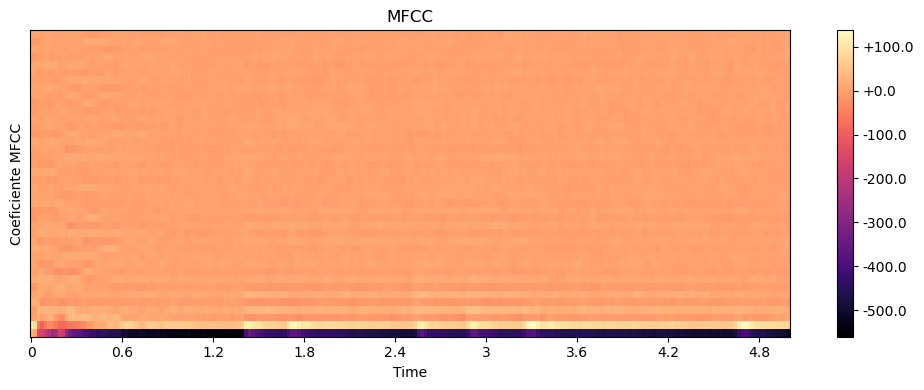

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(
    mfccs,
    x_axis="time",
    sr=sr,
    hop_length=512,        # tiene que coincidir con el usado en mfcc()
    cmap="magma",
    ax=ax,
)
fig.colorbar(img, ax=ax, format="%+.1f")
ax.set(title="MFCC", ylabel="Coeficiente MFCC")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 6.2 DETACH ROCKET . kernels = 5000. 3d
# ==========================================

le = LabelEncoder() # convierte text labels en numeros del 0 a nro_de_clases - 1
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) # me aseguro de que el audio original y sus deformaciones queden todos en train/test

accuracies = [] # guardo resultado de cada fold para despues hacer un promedio
all_y_true = []
all_y_pred = []

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)):
    print(f"\n INICIANDO FOLD {fold+1} DE 5")
        
    # solo consegui que funcionara agregandole esta dimension 
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    X_train_3d = np.expand_dims(X_train, axis=1)
    X_test_3d = np.expand_dims(X_test, axis=1)

    hora_inicio_entrenamiento = time.strftime('%H:%M:%S')
        
    DetachRocketModel = DetachRocket('rocket', num_kernels=5000)
    print(f"   [{hora_inicio_entrenamiento}]")
 
    start_time = time.time()

    DetachRocketModel.fit(X_train_3d, y_train)
    tiempo_entrenamiento = (time.time() - start_time) / 60

    print(f"Entrenamiento listo. Tardó: {tiempo_entrenamiento:.2f} minutos.")

    y_pred = DetachRocketModel.predict(X_test_3d)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    print(f" - Fold {fold+1}: Accuracy = {acc:.4f}")

print("-" * 50)
print(f"Accuracy Promedio (Validado): {np.mean(accuracies):.4f}")

--------------------------------------------------
Total de muestras aumentadas: 960

 INICIANDO FOLD 1 DE 5
   [15:10:35]


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Definimos la forma de entrada y las clases
# Ajusta estas medidas según el tamaño final de tus espectrogramas/MFCCs
input_shape = (40, 216, 1) 
num_classes = 6 # Ej: alarm, door_bell, dog, crying_baby, cat, shouting

def build_pfi_cnn(input_shape, num_classes):
    model = models.Sequential()
    
    # --- BLOQUE DE EXTRACCIÓN DE CARACTERÍSTICAS (VISIÓN) ---
    
    # Capa 1: Busca patrones básicos (líneas, bordes en el sonido)
    model.add(layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2))) # Reduce el tamaño a la mitad
    
    # Capa 2: Busca patrones más complejos (formas específicas del ladrido o sirena)
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Capa 3: Profundiza el análisis sin agregar mucho peso
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # --- BLOQUE DE CLASIFICACIÓN (DECISIÓN) ---
    
    # Aplanamos la matriz 2D resultante a un vector 1D
    model.add(layers.Flatten())
    
    # Capa Densa ("El Cerebro"): Conecta todo lo aprendido
    model.add(layers.Dense(64, activation='relu'))
    
    # Capa de Dropout: ¡VITAL para tu PFI! 
    # Apaga el 50% de las neuronas al azar en cada paso de entrenamiento.
    # Como tienes pocos audios, esto evita que la IA se "memorice" los sonidos (Overfitting).
    model.add(layers.Dropout(0.5))
    
    # Capa de Salida: Una neurona por clase con probabilidades (Softmax)
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    return model

# 2. Instanciamos tu modelo
mi_cnn = build_pfi_cnn(input_shape, num_classes)

# 3. Compilamos el modelo (Le decimos cómo aprender)
mi_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Imprimimos el resumen de la arquitectura
mi_cnn.summary()

/opt/miniconda3/envs/pfi_audio/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 214, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 107, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 105, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 52, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 50, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 25, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       307,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,950 (1.26 MB)

 Trainable params: 330,950 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

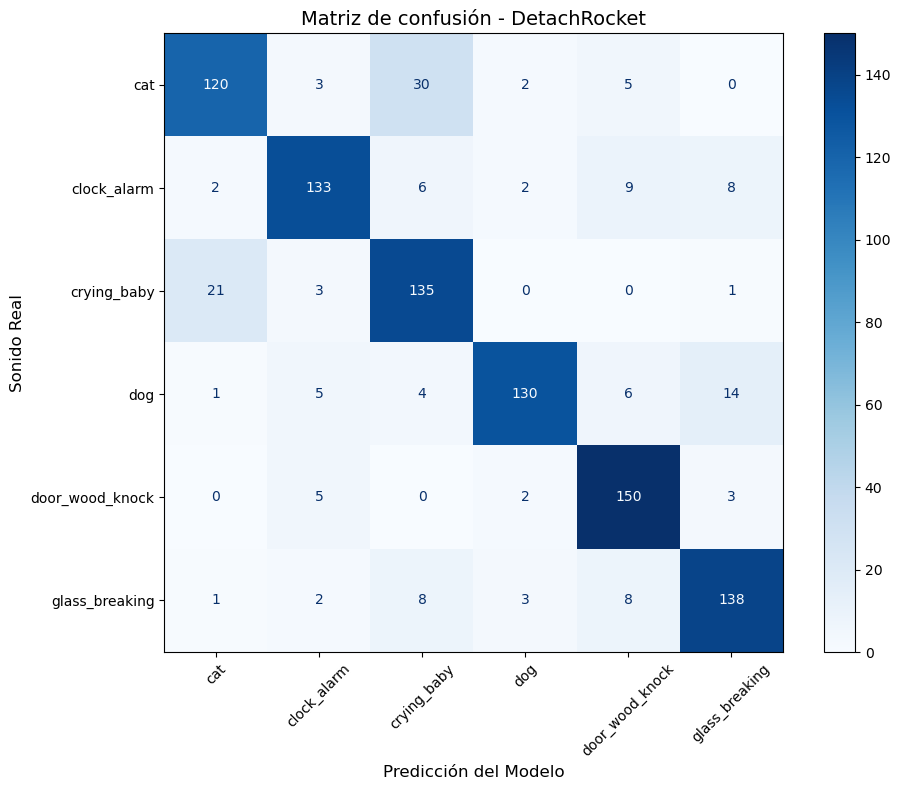

In [16]:
# ==========================================
# 7. MATRIZ DE CONFUSION
# ==========================================

cm = confusion_matrix(all_y_true, all_y_pred)

# Recuperamos los nombres originales de las etiquetas (ej: 'dog', 'siren', etc.)
nombres_clases = le.classes_ 

# Graficamos
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)

plt.title('Matriz de confusión - DetachRocket', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Sonido Real', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
<<PLAYGROUND>>

In [ ]:
# ==========================================
# 5. DETACH ROCKET 
# ==========================================


le = LabelEncoder() #convierte text labels en numeros del 0 a nro_de_clases - 1
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) # me aseguro de que el audio original y sus deformaciones queden todos en train/test

accuracies = [] #guardo resultado de cada fold para despues hacer un promedio

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)): #gkf.split mira los datos, las etiquetas y los identificadores del archivo original y decide de forma inteligente que numeros de fila se usaran para train y test
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
model_type = "rocket"
num_kernels = 10000

DetachRocketModel = DetachRocket(model_type, num_kernels=num_kernels)
# 4. Resultado final (la media de todos los folds)
print("-" * 50)
print(f"Accuracy Promedio (Validado): {np.mean(accuracies):.4f}")

In [ ]:
# ==========================================
# 5. ENTRENAMIENTO CON DETACH-ROCKET
# ==========================================
from sklearn.ensemble import RandomForestClassifier
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("-" * 50)
print("RESUMEN DE AUDIOS UTILIZADOS:")
print(f"Total de muestras (con Data Augmentation): {len(X)}")
print(f" - Muestras para Entrenamiento: {len(X_train)}")
print(f" - Muestras para Prueba (Test): {len(X_test)}")
print("-" * 50)

inicio = time.time()

# Instanciar y ajustar Detach-ROCKET
detach_model = RocketClassifier(num_kernels=500)
detach_model.fit(X_train, y_train)

In [ ]:

# Hacer predicciones sobre el conjunto de prueba
y_pred = detach_model.predict(X_test)

# Calcular la métrica con sklearn
accuracy = accuracy_score(y_test, y_pred)


In [ ]:
accuracy

In [ ]:



# Hacer predicciones sobre el conjunto de prueba
y_pred = detach_model.predict(X_test)

# Calcular la métrica con sklearn
accuracy = accuracy_score(y_test, y_pred)
fin = time.time()

print(f"Precisión (Test Accuracy): {accuracy * 100:.2f}%")
print(f"Tiempo total de ejecución: {fin - inicio:.2f} segundos")

# DetachRocket permite visualizar qué proporción de variables (features) retuvo:
if hasattr(detach_model, 'feature_proportion_'):
    print(f"Porcentaje de features retenidas tras el podado: {detach_model.feature_proportion_ * 100:.2f}%")

# ==========================================
# 6. AUDICIÓN DE VARIANTES
# ==========================================
if 'df_filtrado' in locals() and 'correct_audio_dir' in locals() and correct_audio_dir is not None:
    random_row = df_filtrado.sample(n=1).iloc[0]
    random_file_path = os.path.join(correct_audio_dir, random_row['filename'])
    random_label = random_row['category']

    print("=" * 50)
    print(f"AUDICIÓN DE VARIANTES: {random_label.upper()}")
    print(f"Archivo base: {random_row['filename']}")
    print("=" * 50)

    try:
        y_audio_test, sr_audio = librosa.load(random_file_path, sr=22050)
        
        print("\n1. Audio Original:")
        display(ipd.Audio(y_audio_test, rate=sr_audio))
        
        print("\n2. Variante: Ruido Blanco:")
        y_white = add_white_noise(y_audio_test)
        display(ipd.Audio(y_white, rate=sr_audio))
            
        print("\n3. Variante: Ruido Rosa:")
        y_pink = add_pink_noise(y_audio_test)
        display(ipd.Audio(y_pink, rate=sr_audio))
            
        if babble_audio_full is not None:
            print("\n4. Variante: Murmullo de fondo (Babble Noise):")
            y_babble = add_babble_noise(y_audio_test, babble_audio_full)
            display(ipd.Audio(y_babble, rate=sr_audio))
        else:
            print("\n[Aviso: No se generó Babble Noise válido]")
        
    except Exception as e:
        print(f"Error interno al intentar procesar los audios: {e}")